# Residency Day 2: Advanced Data Mining Project - Deliverable 3

**Name:** Bikram Lamsal  
**Course:** MSCS 634 - Advanced Big Data and Data Mining  
**Title:** Classification, Clustering, and Pattern Mining  
**Date:** July 25, 2026

## Deliverable 3: Classification, Clustering, and Pattern Mining

This deliverable predicts high-value invoices, clusters customers using RFM-style features, and applies association rule mining to product baskets.

These three techniques answer different business questions. Classification asks whether an invoice is likely to be high value. Clustering asks whether customers naturally separate into behavioral groups. Association rule mining asks which products tend to appear together in the same basket. Combining these techniques gives both predictive insight and descriptive pattern discovery.

In [1]:
import os
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

from pathlib import Path
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, roc_auc_score, RocCurveDisplay
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

Matplotlib is building the font cache; this may take a moment.


In [2]:
invoice = pd.read_csv("data/invoice_features.csv", parse_dates=["InvoiceDate"])
customer = pd.read_csv("data/customer_features.csv")
basket_source = pd.read_csv("data/basket_transactions.csv")
print(invoice.shape, customer.shape, basket_source.shape)
invoice.head()

(18532, 12) (4338, 8) (56880, 2)


,InvoiceNo,CustomerID,Country,InvoiceDate,total_quantity,unique_items,line_items,avg_unit_price,invoice_total,InvoiceHour,InvoiceMonth,high_value_invoice
0,536365,17850,United Kingdom,2010-12-01 08:26:00,40,7,7,3.910000,139.12,8,2010-12,0
1,536366,17850,United Kingdom,2010-12-01 08:28:00,12,2,2,1.850000,22.20,8,2010-12,0
2,536367,13047,United Kingdom,2010-12-01 08:34:00,83,12,12,4.853333,278.73,8,2010-12,0
3,536368,13047,United Kingdom,2010-12-01 08:34:00,15,4,4,4.775000,70.05,8,2010-12,0
4,536369,13047,United Kingdom,2010-12-01 08:35:00,3,1,1,5.950000,17.85,8,2010-12,0


In [3]:
invoice["invoice_month_number"] = invoice["InvoiceDate"].dt.month
invoice["invoice_dayofweek"] = invoice["InvoiceDate"].dt.dayofweek
features = ["total_quantity", "unique_items", "line_items", "avg_unit_price", "InvoiceHour", "invoice_month_number", "invoice_dayofweek", "Country"]
X = invoice[features]
y = invoice["high_value_invoice"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42, stratify=y)
preprocess = ColumnTransformer([
    ("num", StandardScaler(), [c for c in features if c != "Country"]),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), ["Country"]),
])

### Classification Setup Rationale

The high-value invoice target is based on the top quartile of invoice totals. This creates a business-oriented classification problem: identify invoices that are more valuable than typical orders. The target is not an original column; it is engineered from revenue so the model can support prioritization decisions. Stratified splitting is used so the training and test sets preserve the same balance of high-value and non-high-value invoices.

In [4]:
classifiers = {
    "Logistic Regression": Pipeline([("prep", preprocess), ("model", LogisticRegression(max_iter=2000))]),
    "Random Forest": Pipeline([("prep", preprocess), ("model", RandomForestClassifier(random_state=42, n_jobs=-1))]),
}
rows=[]
for name, model in classifiers.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    prob = model.predict_proba(X_test)[:, 1]
    rows.append({"model": name, "accuracy": accuracy_score(y_test, pred), "f1": f1_score(y_test, pred), "roc_auc": roc_auc_score(y_test, prob)})
classification_results = pd.DataFrame(rows)
classification_results

,model,accuracy,f1,roc_auc
0,Logistic Regression,0.873752,0.709677,0.924881
1,Random Forest,0.914486,0.817080,0.966991


### Classification Model Interpretation

Logistic Regression provides an interpretable linear baseline, while Random Forest can capture nonlinear splits and feature interactions. Accuracy shows overall correctness, F1 score balances precision and recall for the high-value class, and ROC-AUC measures how well the model ranks high-value invoices across thresholds. Comparing these metrics prevents relying on one number alone.

In [5]:
param_grid = {"model__n_estimators": [100, 200], "model__max_depth": [6, 10, None], "model__min_samples_leaf": [1, 3]}
grid = GridSearchCV(classifiers["Random Forest"], param_grid, cv=3, scoring="f1", n_jobs=-1)
grid.fit(X_train, y_train)
print("Best parameters:", grid.best_params_)
best_rf = grid.best_estimator_
pred = best_rf.predict(X_test)
prob = best_rf.predict_proba(X_test)[:, 1]
tuned_metrics = pd.DataFrame([{
    "model": "Tuned Random Forest",
    "accuracy": accuracy_score(y_test, pred),
    "f1": f1_score(y_test, pred),
    "roc_auc": roc_auc_score(y_test, prob),
}])
tuned_metrics

Best parameters: {'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}


,model,accuracy,f1,roc_auc
0,Tuned Random Forest,0.917723,0.82441,0.968061


### Hyperparameter Tuning Rationale

GridSearchCV is used to reduce arbitrary model selection. Instead of choosing Random Forest parameters manually, the grid search tests combinations of tree count, tree depth, and leaf size using cross-validation. The chosen parameters are those that perform best according to F1 score, which is appropriate because the project cares about identifying high-value invoices without ignoring false positives or false negatives.

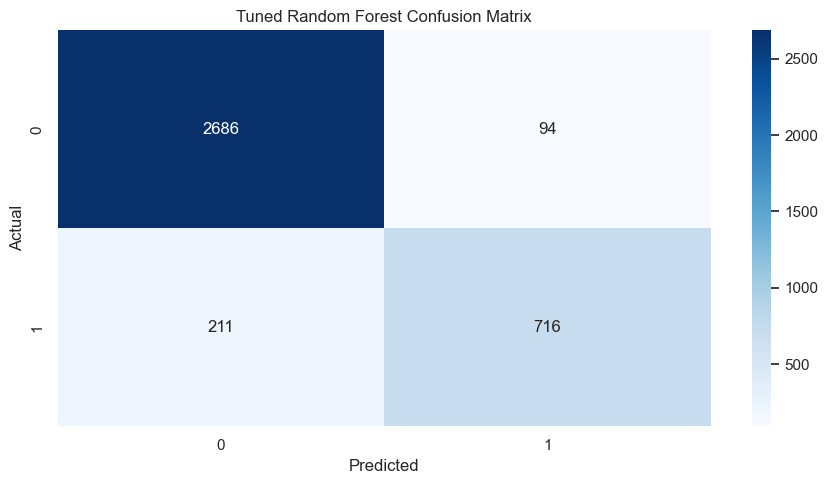

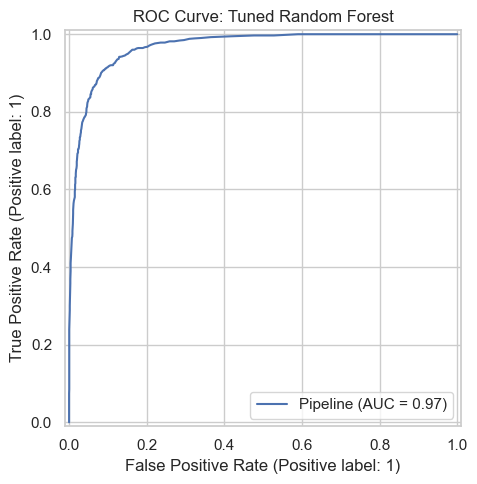

In [6]:
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Tuned Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()
RocCurveDisplay.from_estimator(best_rf, X_test, y_test)
plt.title("ROC Curve: Tuned Random Forest")
plt.tight_layout()
plt.show()

In [7]:
cluster_features = customer[["recency_days", "frequency", "total_quantity", "unique_items", "monetary", "avg_order_value"]].clip(upper=customer[["recency_days", "frequency", "total_quantity", "unique_items", "monetary", "avg_order_value"]].quantile(.99), axis=1)
scaled = StandardScaler().fit_transform(cluster_features)
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
customer["cluster"] = kmeans.fit_predict(scaled)
cluster_summary = customer.groupby("cluster")[["recency_days", "frequency", "monetary", "unique_items"]].mean().round(2)
cluster_summary

,recency_days,frequency,monetary,unique_items
cluster,,,,
0,49.13,2.77,859.75,42.83
1,18.28,31.05,33749.78,223.99
2,26.05,9.84,3864.08,164.39
3,250.75,1.48,440.06,22.41


### Clustering Setup Rationale

Customer clustering uses RFM-style behavior: recency, frequency, monetary value, quantity, product variety, and average order value. These features summarize customer engagement and value. Values are clipped at the 99th percentile before scaling because retail data often contains a few very large wholesale customers. Without clipping, those extreme customers could dominate the distance calculations and make clusters less representative.

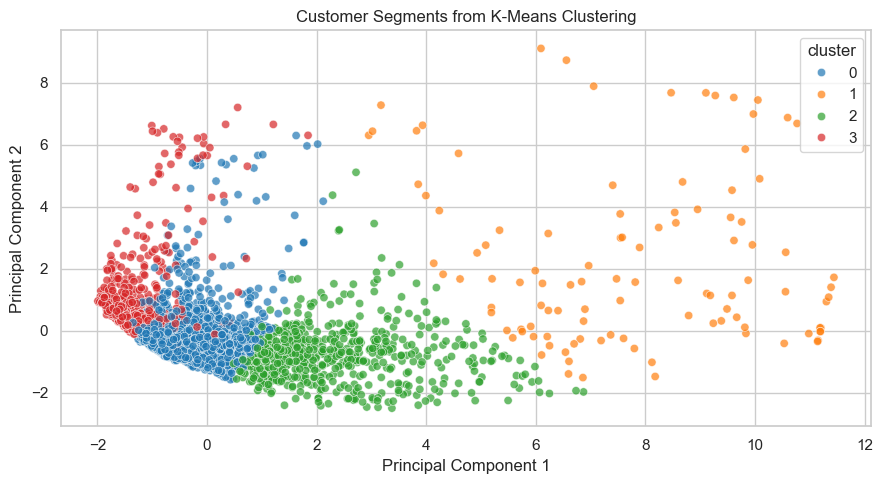

In [8]:
pca = PCA(n_components=2, random_state=42)
points = pca.fit_transform(scaled)
sns.scatterplot(x=points[:,0], y=points[:,1], hue=customer["cluster"], palette="tab10", alpha=.7)
plt.title("Customer Segments from K-Means Clustering")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.tight_layout()
plt.show()

In [9]:
transactions = basket_source.groupby("InvoiceNo")["Description"].apply(lambda s: sorted(set(s))).tolist()
te = TransactionEncoder()
basket = pd.DataFrame(te.fit(transactions).transform(transactions), columns=te.columns_)
itemsets = apriori(basket, min_support=.03, use_colnames=True)
rules = association_rules(itemsets, metric="confidence", min_threshold=.35)
rules["rule"] = rules["antecedents"].apply(lambda x: ", ".join(sorted(x))) + " -> " + rules["consequents"].apply(lambda x: ", ".join(sorted(x)))
rules = rules.sort_values(["lift", "confidence"], ascending=False)
rules[["rule", "support", "confidence", "lift"]].head(10)

,rule,support,confidence,lift
4,GREEN REGENCY TEACUP AND SAUCER -> ROSES REGEN...,0.037129,0.777778,14.706654
5,ROSES REGENCY TEACUP AND SAUCER -> GREEN REGEN...,0.037129,0.702065,14.706654
2,GARDENERS KNEELING PAD CUP OF TEA -> GARDENERS...,0.035725,0.730463,12.620660
3,GARDENERS KNEELING PAD KEEP CALM -> GARDENERS ...,0.035725,0.617251,12.620660
0,ALARM CLOCK BAKELIKE GREEN -> ALARM CLOCK BAKE...,0.035413,0.657971,11.128217
1,ALARM CLOCK BAKELIKE RED -> ALARM CLOCK BAKELI...,0.035413,0.598945,11.128217
34,WOODEN FRAME ANTIQUE WHITE -> WOODEN PICTURE F...,0.035725,0.584184,8.769596
35,WOODEN PICTURE FRAME WHITE FINISH -> WOODEN FR...,0.035725,0.536300,8.769596
32,PAPER CHAIN KIT VINTAGE CHRISTMAS -> PAPER CHA...,0.034087,0.645495,8.756872
31,PAPER CHAIN KIT 50'S CHRISTMAS -> PAPER CHAIN ...,0.034087,0.462434,8.756872


### Association Rule Mining Rationale

Association rule mining is performed on invoice-level product baskets. Each basket contains the distinct products purchased together in one invoice. The analysis is limited to frequent UK products to keep the one-hot matrix and resulting rules interpretable. Apriori then identifies product combinations that meet the support threshold, and association rules explain directional relationships using confidence and lift.

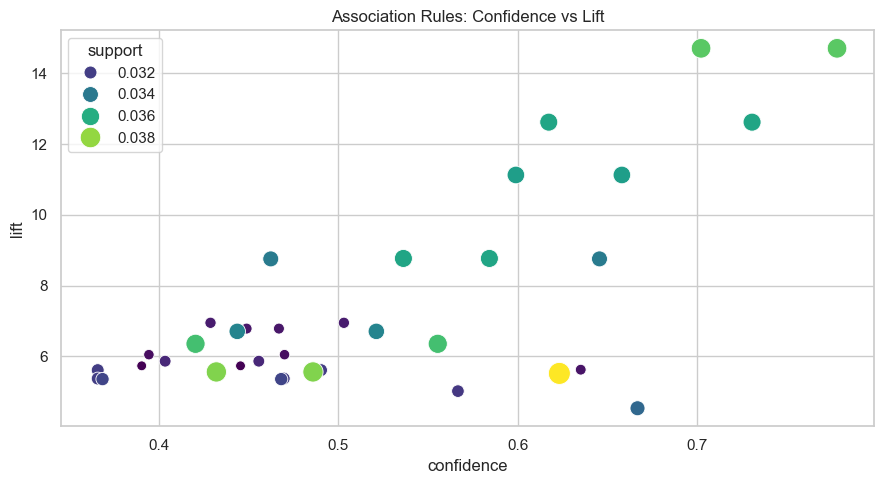

In [10]:
sns.scatterplot(data=rules, x="confidence", y="lift", size="support", hue="support", palette="viridis", sizes=(50,250))
plt.title("Association Rules: Confidence vs Lift")
plt.tight_layout()
plt.show()

### Deliverable 3 Interpretation

Classification converts invoice revenue into a high-value invoice target, which can support customer prioritization and sales forecasting workflows. Hyperparameter tuning is used on Random Forest to improve F1 score and reduce arbitrary model choices. Customer clustering uses RFM-style behavior to identify segments such as recent high-value customers and lower-engagement customers. Association rules reveal products that appear together in baskets, which can support merchandising, bundling, and recommendation decisions.

The outcome of this deliverable is a broader understanding of customer and transaction behavior. Classification helps predict future invoice value, clustering creates customer segments for marketing strategy, and association rules reveal product relationships for cross-selling. These methods should be used together: a high-value customer segment can be targeted with product bundles supported by association rules, while classification can help prioritize which invoices or customers deserve attention.